In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as anime
import funky.snanawrap as f
import pickle
rng=np.random.default_rng(seed=1)

Removed /home/ubuntu/SNANA/SNROOT/SIM/prova/prova_SN000052.DAT bc no obs that t1 - t0 > 10.
Removed /home/ubuntu/SNANA/SNROOT/SIM/prova/prova_SN000082.DAT bc no obs that t1 - t0 < 0.


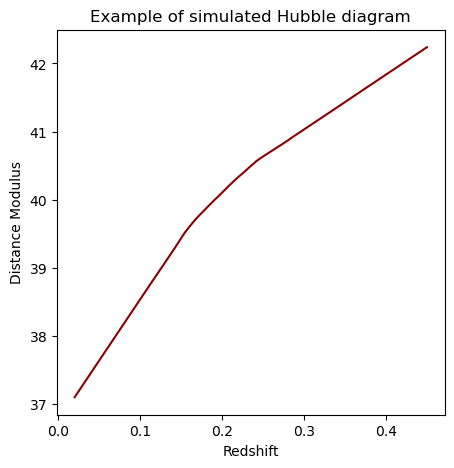

In [16]:
mu, zhd= f.sim_wrapper([0.34,-1],'prova')
z_sim,mu_sim=(f.smoother(zhd,mu))
plt.figure(figsize=(5,5))

plt.plot(z_sim,mu_sim,c='darkred')
plt.title('Example of simulated Hubble diagram')
plt.xlabel('Redshift')
plt.ylabel('Distance Modulus')
plt.show()

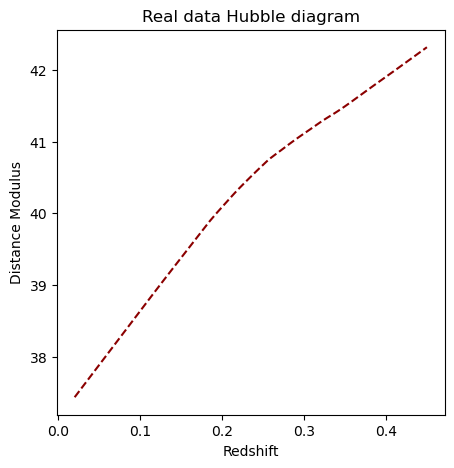

In [21]:
mu_data,z_data=f.extract_mu_zhd_from_file('/home/ubuntu/SNANA/salt2mus/realdata/SALT2mu_realdata.FITRES')
# summary statistic of real data
z_data,mu_data=(f.smoother(z_data,mu_data))
plt.figure(figsize=(5,5))
plt.plot(z_data,mu_data,c='darkred',ls='dashed')
plt.title('Real data Hubble diagram')
plt.xlabel('Redshift')
plt.ylabel('Distance Modulus')
plt.show()

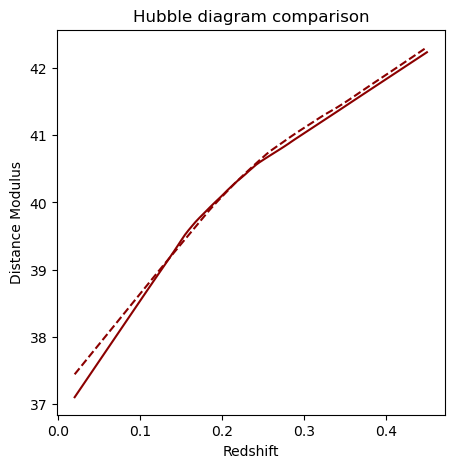

In [22]:


plt.figure(figsize=(5,5))
plt.plot(z_data,mu_data,c='darkred',ls='dashed')
plt.plot(z_sim,mu_sim,c='darkred')

plt.title('Hubble diagram comparison')
plt.xlabel('Redshift')
plt.ylabel('Distance Modulus')
plt.show()

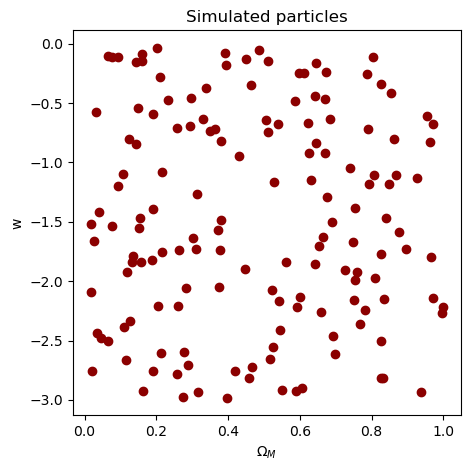

In [ ]:
with open("/home/ubuntu/SNANA/nre/nreSims.pickle", "rb") as fin: preSim = pickle.load(fin)
    
N=150
theta_t = np.empty((N, 2)) 
for n in range(N):
    sim = preSim[n]
    theta_t[n] = (sim['omega'], sim['w'])  
del preSim

plt.figure(figsize=(5,5))
plt.scatter(theta_t[:,0],theta_t[:,1], c='darkred')
plt.title('Simulated particles')
plt.xlabel(r'$\Omega_M$')
plt.ylabel('w')
plt.show()

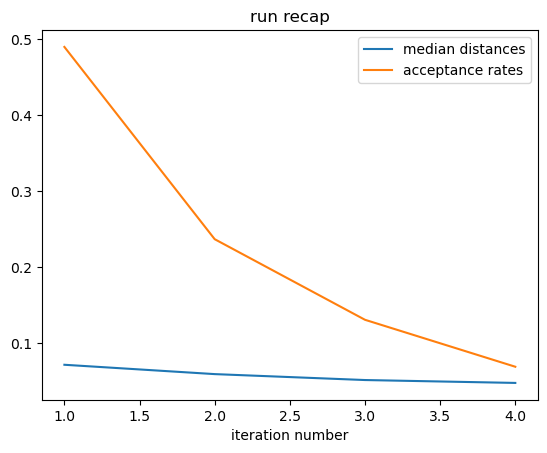

In [8]:
#plt.plot(range(len(eps)),eps,label='epsilon')
plt.plot(range(1,len(medians)+1),medians,label='median distances')
plt.plot(range(1,len(acc_rates)+1),acc_rates, label='acceptance rates')

plt.title ('run recap')
plt.xlabel('iteration number')
plt.legend()
plt.show()

# Unpickle the jar!

In [44]:
len(thetaDraw)

9

<class 'dict'>
eps
medians
acc_rates
theta_history
tau_history


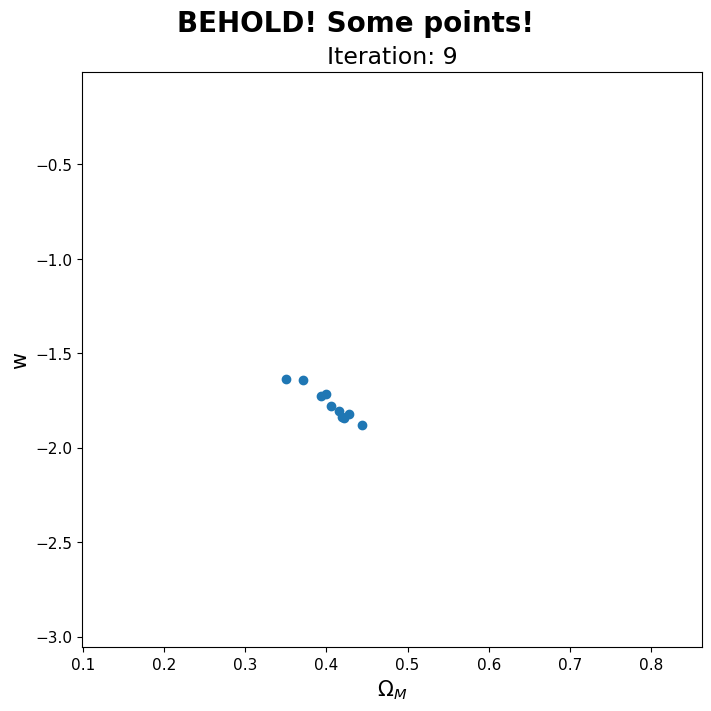

In [ ]:
with open("outLists.pickle", "rb") as fin: dataLoad = pickle.load(fin)
print(type(dataLoad))

for key, item in dataLoad.items(): print(key)
thetaDraw = dataLoad["theta_history"]
fig, ax = plt.subplots(figsize=(7,7), layout="constrained")
fig.suptitle("Iteration results", weight="bold", fontsize=20)
title = ax.set_title("Iteration: 1", fontsize=17)
ax.set_xlabel(r"$\Omega_M$", fontsize=15)
ax.set_ylabel("w", fontsize=15)
ax.tick_params(axis="both", which="major", labelsize=11)

scrat = ax.scatter(thetaDraw[0][:, 0], thetaDraw[0][:, 1])


def update(frame):
    scrat.set_offsets(thetaDraw[frame])
    title.set_text(f"Iteration: {frame + 1}")
    return (scrat, title)

ani = anime.FuncAnimation(fig=fig, func=update, frames=len(thetaDraw), interval=700, blit=True)
    
ani.save(filename='plswrk.gif', writer="pillow")